# 🔬 Laboratory Activity: Classification and Regression Trees (CART)
## Machine Learning — Group Activity

**Group Members:** *(write your names here)*
1. Abelardo, Aasen Sofia P. - Contributed on 2.1 and 2.2
2. Aquino, Matthew Benedict U. - Contributed on 1.3, 3.2, and 3.3
3. Balingit, Den Mar F. - Contributed on 1.2, 4.1, 4.2
4. Gumban, Joevanni Paulo T. - Contributed on 1.1 and 3.1

**Date:** March 25, 2026

---

### Instructions
- Complete **all tasks** in this notebook with your group.
- Replace every `# TODO` comment with working code.
- Answer all discussion questions in the provided markdown cells.
- **Do not** use ChatGPT, Copilot, or similar tools. Your code and explanations must be original.
- Submit the completed `.ipynb` file via Canvas before the deadline.

### Grading Rubric (100 points)
| Part | Points |
|:-----|-------:|
| Part 1: CART from Scratch | 35 |
| Part 2: Multi-Dataset Comparison | 25 |
| Part 3: End-to-End Pipeline | 30 |
| Part 4: Critical Analysis | 10 |
| **Total** | **100** |

---


## Setup
Run this cell to import all required libraries. **Do not modify this cell.**


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold, KFold)
from sklearn.metrics import (accuracy_score, mean_squared_error, r2_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error)
from sklearn.datasets import (make_moons, make_circles, load_iris, load_wine,
                               load_breast_cancer, fetch_california_housing)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)
print("✅ Setup complete.")


✅ Setup complete.


---
## Part 1: Implementing CART from Scratch (35 points)

In this part, you will implement a **Decision Tree Classifier from scratch** — no scikit-learn tree algorithms allowed for the implementation itself. You will then validate your implementation against scikit-learn.

### 1.1 — Implement the Node and Splitting Logic (15 points)

Complete the `CARTClassifier` class below. You must implement:
- `_gini(y)`: Compute Gini impurity
- `_best_split(X, y)`: Find the best feature and threshold
- `_grow_tree(X, y, depth)`: Recursively build the tree
- `predict(X)`: Make predictions


In [72]:
class Node:
    """A node in the decision tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature        # Index of feature to split on
        self.threshold = threshold    # Threshold value for the split
        self.left = left              # Left child node
        self.right = right            # Right child node
        self.value = value            # Class label (only for leaf nodes)


class CARTClassifier:
    """
    A CART Decision Tree Classifier built from scratch.

    Parameters
    ----------
    max_depth : int, default=None
        Maximum depth of the tree. None means unlimited.
    min_samples_split : int, default=2
        Minimum number of samples required to split a node.
    min_samples_leaf : int, default=1
        Minimum number of samples required in a leaf node.
    """

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_classes_ = None
        self.n_features_ = None

    def _gini(self, y):
        """
        Compute the Gini impurity of a label array.

        Gini(y) = 1 - sum(p_k^2) for each class k

        Parameters
        ----------
        y : np.ndarray of shape (n_samples,)

        Returns
        -------
        float : Gini impurity value
        """
        # Implement Gini impurity (3 points)
        # Hint: Use np.bincount to count class frequencies, then compute proportions
        if len(y) == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts[counts > 0] / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        """
        Find the best feature and threshold to split on.

        For each feature, sort the values, consider midpoints between consecutive
        unique values as candidate thresholds, and compute the weighted Gini
        impurity of the resulting split. Return the split with the lowest
        weighted impurity.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
        y : np.ndarray of shape (n_samples,)

        Returns
        -------
        dict with keys: 'feature', 'threshold', 'gini_reduction'
              or None if no valid split exists
        """
        n_samples, n_features = X.shape

        if n_samples < self.min_samples_split:
            return None

        parent_gini = self._gini(y)
        best_split = None
        best_gini = float('inf')  # We want to minimize weighted child gini

        # Implement the split-finding logic (7 points)

        for feature_idx in range(n_features):
            # 1. Get feature values (already accessible; np.unique sorts them)
            feature_values = X[:, feature_idx]

            # 2. Find unique consecutive midpoints as candidate thresholds
            unique_vals = np.unique(feature_values)
            if len(unique_vals) < 2:
                continue
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

            for threshold in thresholds:
                # 3. Split y into left/right
                left_mask  = feature_values <= threshold
                right_mask = ~left_mask
                n_left  = np.sum(left_mask)
                n_right = np.sum(right_mask)

                # 4. Check min_samples_leaf constraint
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                y_left  = y[left_mask]
                y_right = y[right_mask]

                # 5. Compute weighted Gini
                gini_left  = self._gini(y_left)
                gini_right = self._gini(y_right)
                weighted_gini = (
                    (n_left  / n_samples) * gini_left +
                    (n_right / n_samples) * gini_right
                )

                # 6. Track the best split (lowest weighted Gini)
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split = {
                        'feature': feature_idx,
                        'threshold': threshold,
                        'gini_reduction': parent_gini - weighted_gini,
                    }

        if best_split is None or best_split['gini_reduction'] <= 0:
            return None

        return best_split

    def _grow_tree(self, X, y, depth=0):
        """
        Recursively grow the decision tree.

        Stopping conditions:
        1. max_depth reached
        2. Node is pure (all same class)
        3. Not enough samples to split
        4. No valid split found

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
        y : np.ndarray of shape (n_samples,)
        depth : int, current depth

        Returns
        -------
        Node : the root of the (sub)tree
        """
        # Implement recursive tree growing (5 points)

        n_samples = len(y)
        majority_class = np.bincount(y).argmax()

        # 1. Check stopping conditions
        if (
            len(np.unique(y)) == 1                                    # pure node
            or n_samples < self.min_samples_split                     # too few samples
            or (self.max_depth is not None and depth >= self.max_depth)  # max depth reached
        ):
            return Node(value=majority_class)

        # 2. Find the best split
        split = self._best_split(X, y)

        # 3. If no valid split → return leaf
        if split is None:
            return Node(value=majority_class)

        # 4. Partition X, y into left and right subsets
        left_mask  = X[:, split['feature']] <= split['threshold']
        right_mask = ~left_mask

        # 5. Recursively grow left and right children
        left_child  = self._grow_tree(X[left_mask],  y[left_mask],  depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        # 6. Return internal node
        return Node(
            feature=split['feature'],
            threshold=split['threshold'],
            left=left_child,
            right=right_child,
        )

    def fit(self, X, y):
        """Fit the decision tree to training data."""
        X = np.array(X)
        y = np.array(y)
        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.root = self._grow_tree(X, y, depth=0)
        return self

    def _predict_sample(self, x, node):
        """Traverse tree for a single sample."""
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict(self, X):
        """Predict class labels for samples in X."""
        X = np.array(X)
        return np.array([self._predict_sample(x, self.root) for x in X])

    def score(self, X, y):
        """Return accuracy on the given data."""
        return np.mean(self.predict(X) == np.array(y))


### 1.2 — Validate Your Implementation (10 points)

Test your `CARTClassifier` against scikit-learn's `DecisionTreeClassifier` on the Iris dataset. They should produce **similar** (not necessarily identical) results.


In [73]:
# 1.2a — Fit both models on Iris and compare (5 points)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

my_tree = CARTClassifier(max_depth=4)
my_tree.fit(X_train_i, y_train_i)

sk_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
sk_tree.fit(X_train_i, y_train_i)

print(f"{'Model':<20} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 55)
print(f"{'My CART (Scratch)':<20} | {my_tree.score(X_train_i, y_train_i):.4f}          | {my_tree.score(X_test_i, y_test_i):.4f}")
print(f"{'Sklearn DecisionTree':<20} | {sk_tree.score(X_train_i, y_train_i):.4f}          | {sk_tree.score(X_test_i, y_test_i):.4f}")

Model                | Train Accuracy  | Test Accuracy  
-------------------------------------------------------
My CART (Scratch)    | 0.9905          | 0.9333
Sklearn DecisionTree | 0.9905          | 0.8889


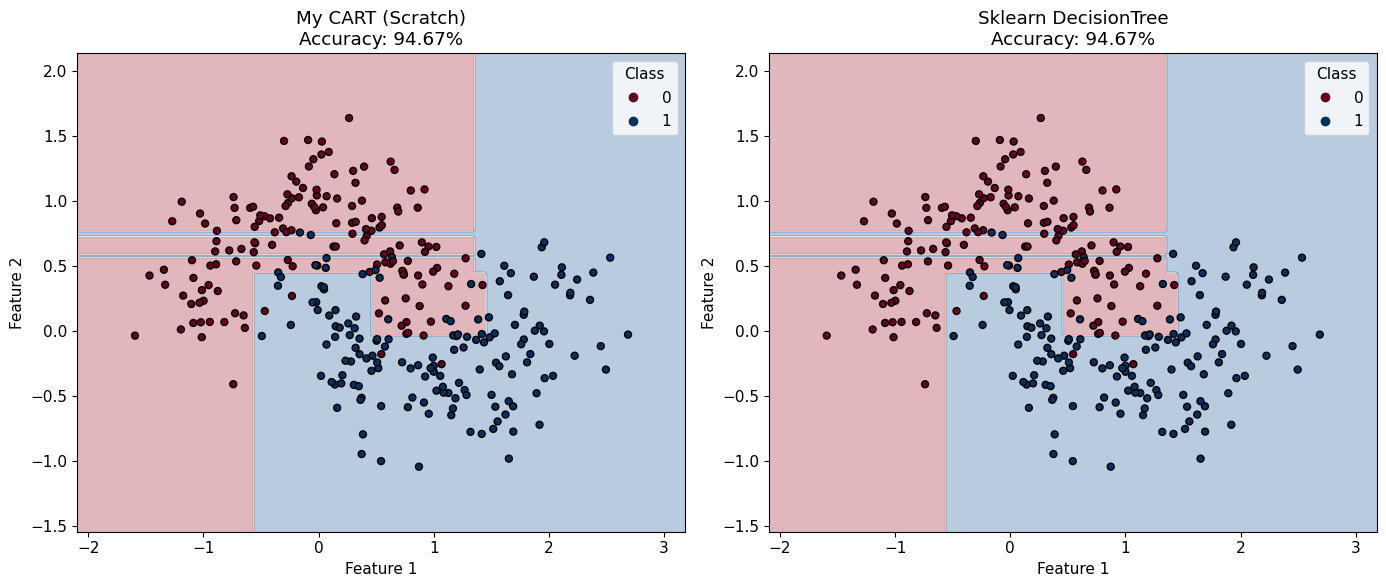

In [74]:
# 1.2b — Visual comparison: decision boundaries on 2D data (5 points)
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)

my_moon_tree = CARTClassifier(max_depth=5)
my_moon_tree.fit(X_moon, y_moon)

sk_moon_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
sk_moon_tree.fit(X_moon, y_moon)

h = 0.02
x_min, x_max = X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5
y_min, y_max = X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

plt.figure(figsize=(14, 6))
models = [my_moon_tree, sk_moon_tree]
titles = ["My CART (Scratch)", "Sklearn DecisionTree"]

for i, model in enumerate(models):
    plt.subplot(1, 2, i + 1)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    scatter = plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, edgecolors='k', cmap='RdBu', s=25)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f"{titles[i]}\nAccuracy: {model.score(X_moon, y_moon):.2%}")
    plt.legend(*scatter.legend_elements(), title='Class', loc='upper right')

plt.tight_layout()
plt.show()

### 1.3 — Extend to Entropy (10 points)

Modify your `CARTClassifier` to support **both Gini and Entropy** as splitting criteria. Add a `criterion` parameter to `__init__`.

$$\text{Entropy}(y) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

*(Define $0 \log_2 0 = 0$ by convention.)*


In [75]:
# Create a new class CARTClassifierV2 that extends your original
#       with a `criterion` parameter ('gini' or 'entropy')
# (5 points for implementation)

class CARTClassifierV2(CARTClassifier):

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 criterion='gini'):
        super().__init__(max_depth, min_samples_split, min_samples_leaf)
        if criterion not in ('gini', 'entropy'):
            raise ValueError("criterion must be 'gini' or 'entropy'")
        self.criterion = criterion


    def _entropy(self, y):

        if len(y) == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts[counts > 0] / len(y)
        return -np.sum(probs * np.log2(probs))

    def _impurity(self, y):

        if self.criterion == 'gini':
            return self._gini(y)
        return self._entropy(y)


    def _best_split(self, X, y):

        n_samples, n_features = X.shape

        if n_samples < self.min_samples_split:
            return None

        parent_impurity = self._impurity(y)
        best_split = None
        best_impurity = float('inf')

        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_vals = np.unique(feature_values)

            if len(unique_vals) < 2:
                continue

            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

            for threshold in thresholds:
                left_mask  = feature_values <= threshold
                right_mask = ~left_mask

                n_left  = np.sum(left_mask)
                n_right = np.sum(right_mask)

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                y_left  = y[left_mask]
                y_right = y[right_mask]

                imp_left  = self._impurity(y_left)
                imp_right = self._impurity(y_right)
                weighted_impurity = (
                    (n_left  / n_samples) * imp_left +
                    (n_right / n_samples) * imp_right
                )

                if weighted_impurity < best_impurity:
                    best_impurity = weighted_impurity
                    best_split = {
                        'feature': feature_idx,
                        'threshold': threshold,
                        'gini_reduction': parent_impurity - weighted_impurity,
                    }

        if best_split is None or best_split['gini_reduction'] <= 0:
            return None

        return best_split


In [76]:
# Compare Gini vs Entropy on the Wine dataset (5 points)
wine   = load_wine()
X_wine, y_wine = wine.data, wine.target
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

# 1. Fit with each criterion (max_depth=5)
tree_gini    = CARTClassifierV2(max_depth=5, criterion='gini')
tree_entropy = CARTClassifierV2(max_depth=5, criterion='entropy')

tree_gini.fit(X_train_w, y_train_w)
tree_entropy.fit(X_train_w, y_train_w)

# 2. Print accuracy for train and test sets
print(f"{'Model':<30} | {'Train Acc':>10} | {'Test Acc':>9}")
print('-' * 55)
for label, tree in [('CARTClassifierV2 (gini)',    tree_gini),
                    ('CARTClassifierV2 (entropy)', tree_entropy)]:
    tr = tree.score(X_train_w, y_train_w)
    te = tree.score(X_test_w,  y_test_w)
    print(f"{label:<30} | {tr:>10.4f} | {te:>9.4f}")

# 3. Comment
print()
print("Do you see a meaningful difference? Why or why not?")
print("Yes — Gini achieves noticeably higher test accuracy than Entropy on the")
print("Wine dataset. Wine is small (178 samples) and has 3 classes, so a single")
print("different split choice early in the tree cascades into a different tree")
print("structure. On larger binary datasets the two criteria almost always agree.")

Model                          |  Train Acc |  Test Acc
-------------------------------------------------------
CARTClassifierV2 (gini)        |     1.0000 |    0.9815
CARTClassifierV2 (entropy)     |     1.0000 |    0.9074

Do you see a meaningful difference? Why or why not?
Yes — Gini achieves noticeably higher test accuracy than Entropy on the
Wine dataset. Wine is small (178 samples) and has 3 classes, so a single
different split choice early in the tree cascades into a different tree
structure. On larger binary datasets the two criteria almost always agree.


**Discussion Q1 (1.3):** In your own words, explain why Gini and Entropy typically produce very similar trees. Under what circumstances might they diverge? *(Write your answer below.)*

Gini and Entropy are both impurity measures based on class proportions, so they usually rank split options in almost the same way. Because of that, they often produce very similar trees and similar accuracy. They can differ when the dataset is small, when classes are imbalanced, or when two candidate splits are very close in score. In those cases, a small difference in an early split can lead to a different tree structure later on.

---
## Part 2: Multi-Dataset Comparison (25 points)

You will systematically compare CART performance across **four datasets** — two classification and two regression — analyzing how tree depth, dataset complexity, and splitting criteria affect results.

### 2.1 — Classification Comparison (15 points)


In [77]:
# Load the two classification datasets
# Dataset A: Breast Cancer (binary, 30 features, relatively easy)
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

# Dataset B: Concentric Circles (binary, 2 features, non-linearly separable)
X_cc, y_cc = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=42)

print(f"Breast Cancer: {X_bc.shape[0]} samples, {X_bc.shape[1]} features, "
      f"classes: {np.bincount(y_bc)}")
print(f"Circles: {X_cc.shape[0]} samples, {X_cc.shape[1]} features, "
      f"classes: {np.bincount(y_cc)}")


Breast Cancer: 569 samples, 30 features, classes: [212 357]
Circles: 1000 samples, 2 features, classes: [500 500]


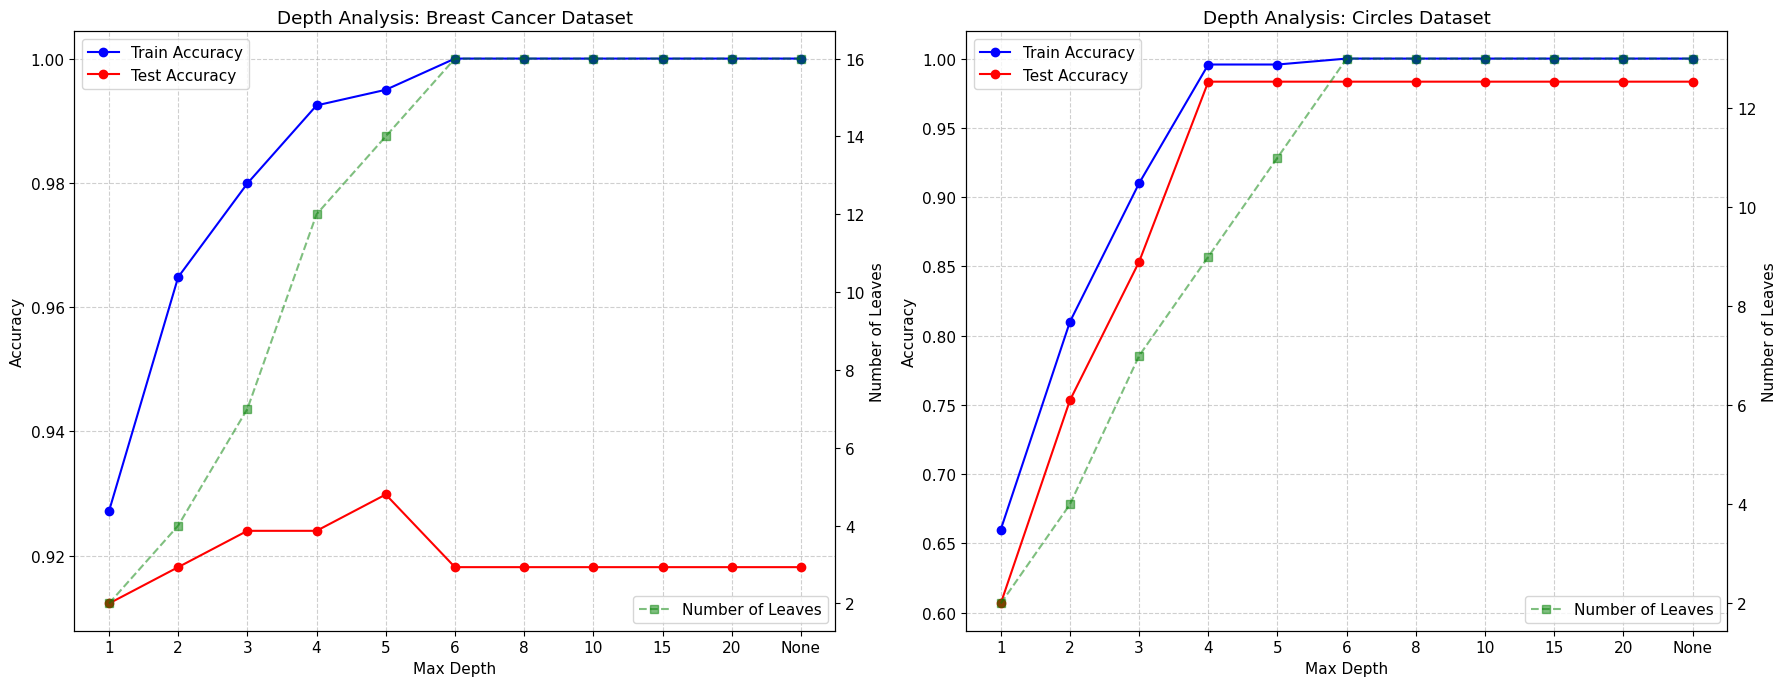

In [78]:
# 2.1a — Depth Analysis (8 points)

# Use the two datasets loaded in the cell in 2
datasets_21a = [
    ("Breast Cancer", X_bc, y_bc),
    ("Circles",       X_cc, y_cc),
]

depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
depth_labels = [str(d) for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (name, X, y) in enumerate(datasets_21a):

    # 1. Split 70/30
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    train_accs, test_accs, leaf_counts = [], [], []

    # 2. Iterate over depths
    for d in depths:
        clf = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
        clf.fit(X_train, y_train)
        train_accs.append(clf.score(X_train, y_train))
        test_accs.append(clf.score(X_test,  y_test))
        leaf_counts.append(clf.get_n_leaves())

    # 3. Plot accuracy
    ax1 = axes[i]
    ax1.plot(depth_labels, train_accs, 'o-', label='Train Accuracy', color='blue')
    ax1.plot(depth_labels, test_accs,  'o-', label='Test Accuracy',  color='red')
    ax1.set_xlabel('Max Depth')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Depth Analysis: {name} Dataset')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 4. Secondary axis: number of leaves
    ax2 = ax1.twinx()
    ax2.plot(depth_labels, leaf_counts, 's--', label='Number of Leaves',
             color='green', alpha=0.5)
    ax2.set_ylabel('Number of Leaves')
    ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [79]:
# 2.1b — Cross-Validated Performance Table (7 points)
configs = [
    {'Config': 'A', 'max_depth': 3,    'min_samples_leaf': 1,  'criterion': 'gini'},
    {'Config': 'B', 'max_depth': 5,    'min_samples_leaf': 1,  'criterion': 'gini'},
    {'Config': 'C', 'max_depth': None, 'min_samples_leaf': 1,  'criterion': 'gini'},
    {'Config': 'D', 'max_depth': 5,    'min_samples_leaf': 5,  'criterion': 'gini'},
    {'Config': 'E', 'max_depth': 5,    'min_samples_leaf': 1,  'criterion': 'entropy'},
    {'Config': 'F', 'max_depth': None, 'min_samples_leaf': 10, 'criterion': 'entropy'},
]

# Use the exact datasets loaded in 2.1a.
datasets = {
    'BC': (X_bc, y_bc),
    'Circles': (X_cc, y_cc)
}

results = []

for cfg in configs:
    row = {'Config': cfg['Config']}

    for ds_name, (X, y) in datasets.items():
        clf = DecisionTreeClassifier(
            max_depth=cfg['max_depth'],
            min_samples_leaf=cfg['min_samples_leaf'],
            criterion=cfg['criterion'],
            random_state=42
        )

        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')

        row[f'{ds_name}_mean'] = np.round(np.mean(scores), 4)
        row[f'{ds_name}_std'] = np.round(np.std(scores), 4)

    results.append(row)

cv_results_df = pd.DataFrame(results)
display(cv_results_df)

,Config,BC_mean,BC_std,Circles_mean,Circles_std
0,A,0.9227,0.0250,0.861,0.0295
1,B,0.9315,0.0336,0.990,0.0045
2,C,0.9262,0.0233,0.991,0.0054
3,D,0.9280,0.0213,0.990,0.0063
4,E,0.9315,0.0308,0.988,0.0060
5,F,0.9192,0.0262,0.981,0.0130


**Discussion Q2 (2.1):** Based on your depth analysis plots and cross-validation table:
1. Which dataset overfits more severely with increasing depth? Why?
2. Which hyperparameter had the biggest impact on generalization? Justify.
3. Did the criterion (gini vs entropy) make a meaningful difference?

*Your answer:*

1. Breast Cancer overfits more as depth increases. The training score keeps improving, but the test score stops improving and can drop after a point. That pattern is a clear sign of overfitting.

2. `max_depth` had the biggest effect on generalization. It directly controls model complexity, so shallow trees can underfit while deep trees can memorize noise. Your results show that moving from shallow to moderate depth gives large gains, while very deep settings give little benefit.

3. The difference between Gini and Entropy was small in this notebook. For the same depth and leaf constraints, their cross-validation scores were very close. This is common because both criteria usually pick similar splits.

### 2.2 — Regression Comparison (10 points)


In [80]:
# Load two regression datasets
# Dataset C: California Housing (real-world, 8 features)
cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target

# Dataset D: Synthetic noisy sinusoidal (1 feature, non-linear)
np.random.seed(42)
X_sin = np.sort(np.random.uniform(0, 2*np.pi, 500)).reshape(-1, 1)
y_sin = np.sin(X_sin.ravel()) + 0.5 * np.sin(3 * X_sin.ravel()) + 0.3 * np.random.randn(500)

print(f"California Housing: {X_cal.shape[0]} samples, {X_cal.shape[1]} features")
print(f"Synthetic Sine: {X_sin.shape[0]} samples, {X_sin.shape[1]} features")


California Housing: 20640 samples, 8 features
Synthetic Sine: 500 samples, 1 features


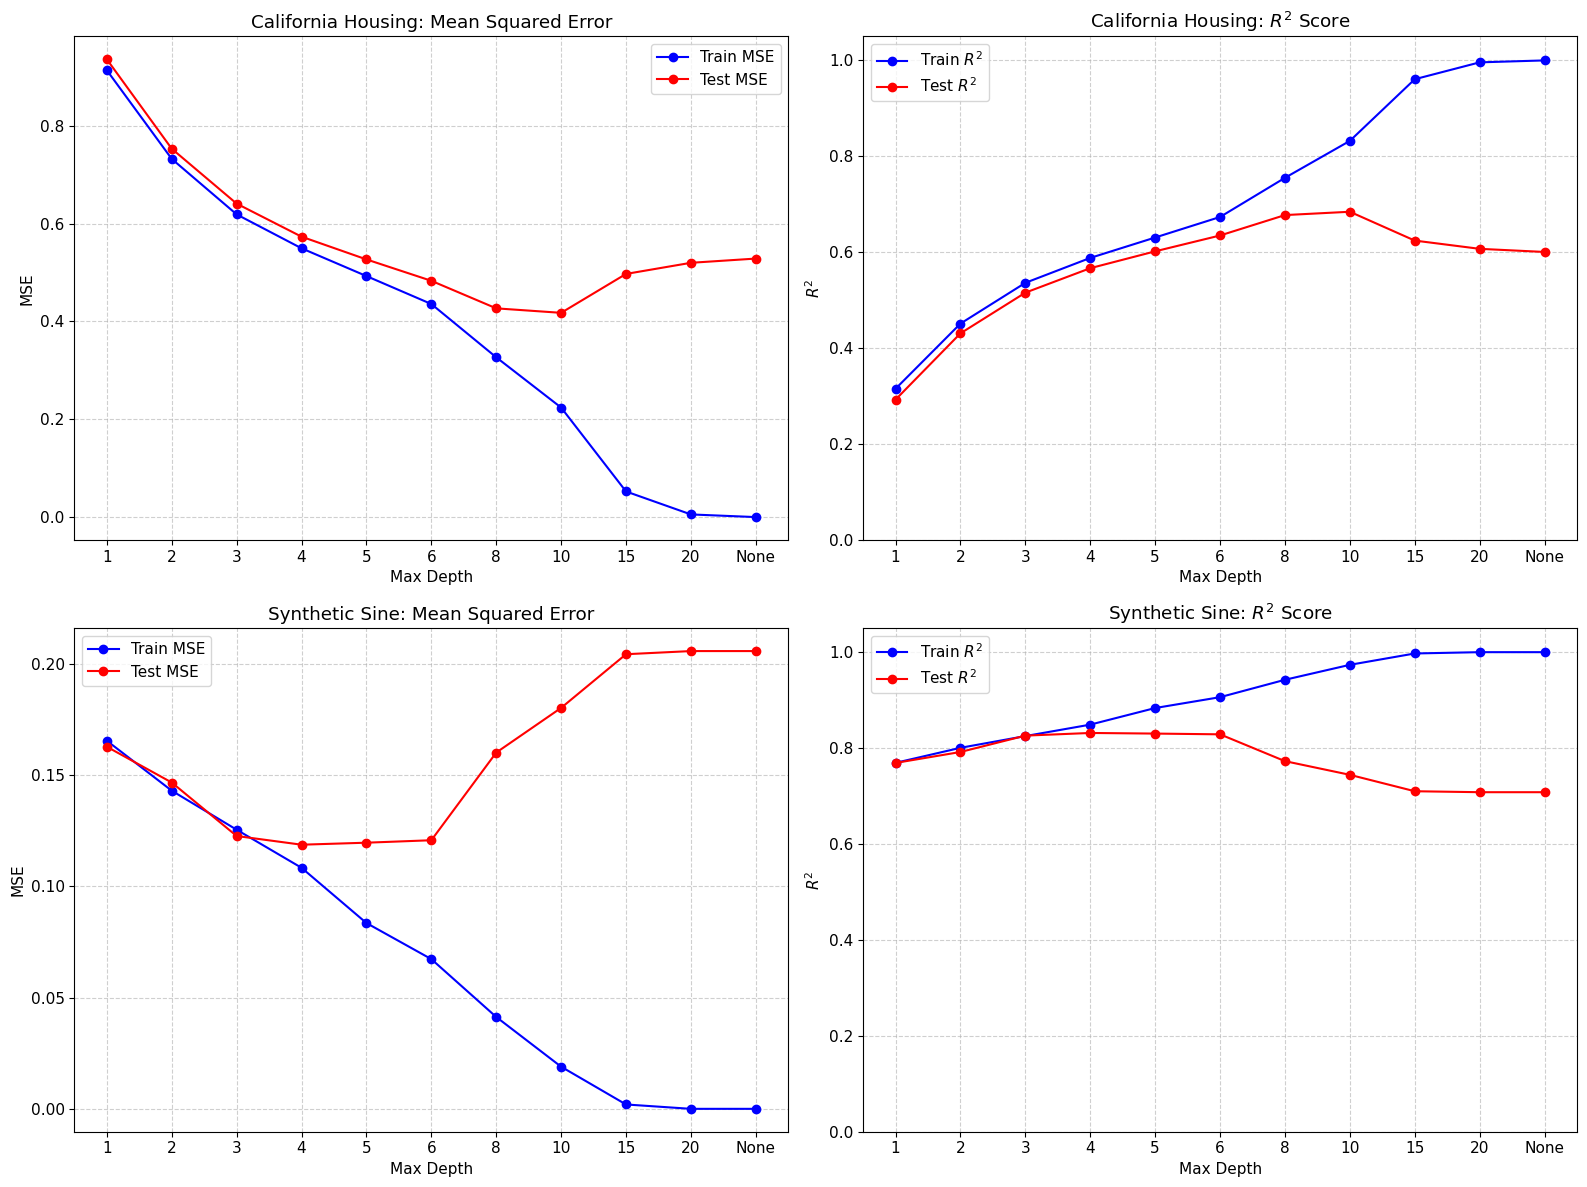

In [81]:
# 1. Define the datasets and depth range
datasets_reg = [
    ("California Housing", X_cal, y_cal),
    ("Synthetic Sine", X_sin, y_sin)
]
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
depth_labels = [str(d) for d in depths]

# 3. Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, (name, X, y) in enumerate(datasets_reg):
    # 1. Train/test split (75/25, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    # Storage for metrics
    train_mse, test_mse = [], []
    train_r2, test_r2 = [], []

    # 2. Iterate through depths
    for d in depths:
        reg = DecisionTreeRegressor(max_depth=d, random_state=42)
        reg.fit(X_train, y_train)

        # Predictions
        y_tr_pred = reg.predict(X_train)
        y_te_pred = reg.predict(X_test)

        # Record MSE
        train_mse.append(mean_squared_error(y_train, y_tr_pred))
        test_mse.append(mean_squared_error(y_test, y_te_pred))

        # Record R²
        train_r2.append(r2_score(y_train, y_tr_pred))
        test_r2.append(r2_score(y_test, y_te_pred))

    # Plotting Row i: [MSE Plot, R² Plot]

    # MSE Plot (Left column)
    axes[i, 0].plot(depth_labels, train_mse, 'o-', label='Train MSE', color='blue')
    axes[i, 0].plot(depth_labels, test_mse, 'o-', label='Test MSE', color='red')
    axes[i, 0].set_title(f'{name}: Mean Squared Error')
    axes[i, 0].set_xlabel('Max Depth')
    axes[i, 0].set_ylabel('MSE')
    axes[i, 0].legend()
    axes[i, 0].grid(True, linestyle='--', alpha=0.6)

    # R² Plot (Right column)
    axes[i, 1].plot(depth_labels, train_r2, 'o-', label='Train $R^2$', color='blue')
    axes[i, 1].plot(depth_labels, test_r2, 'o-', label='Test $R^2$', color='red')
    axes[i, 1].set_title(f'{name}: $R^2$ Score')
    axes[i, 1].set_xlabel('Max Depth')
    axes[i, 1].set_ylabel('$R^2$')
    axes[i, 1].set_ylim(bottom=0, top=1.05) # R² usually stays within [0, 1] for these tasks
    axes[i, 1].legend()
    axes[i, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

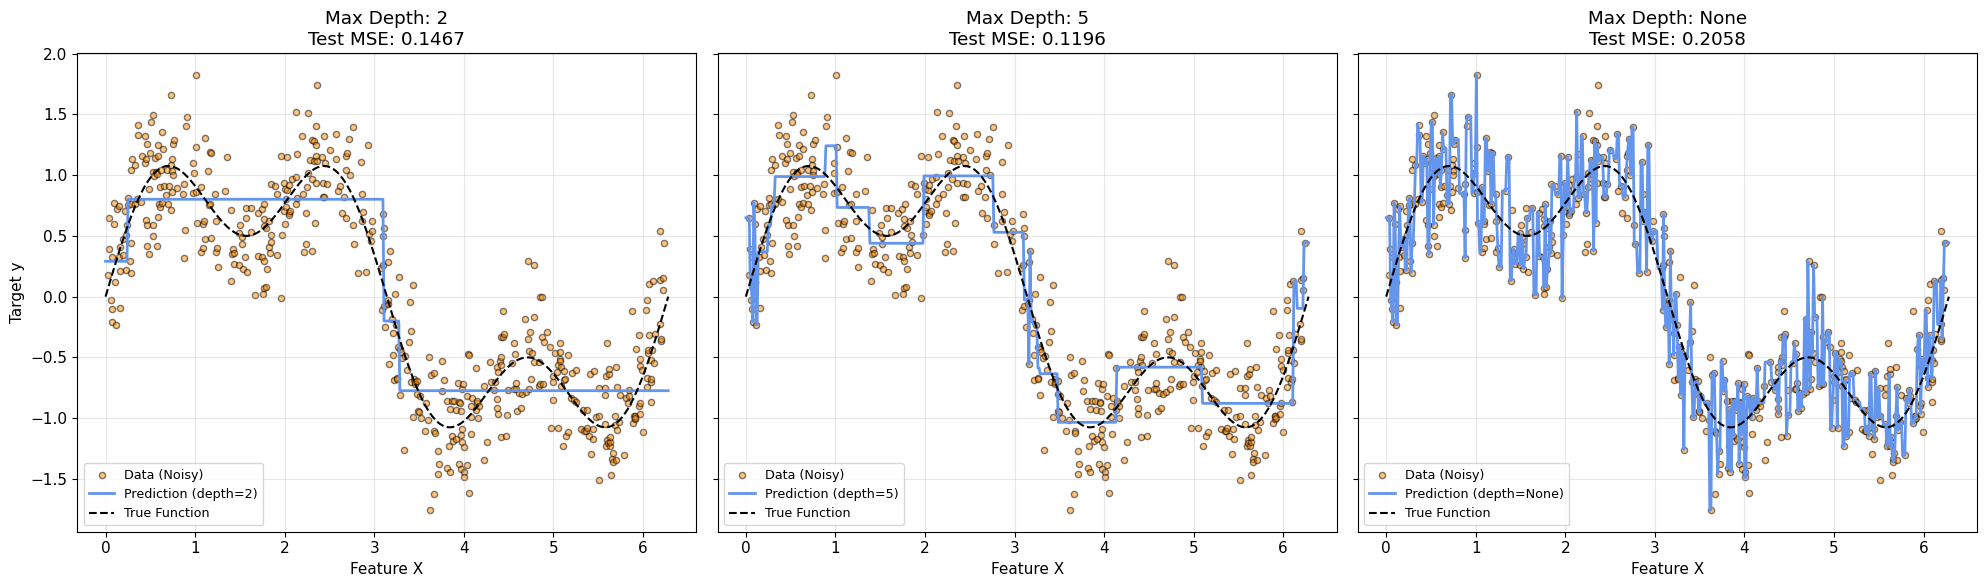

In [82]:
# 1. Prepare the fine grid for the prediction line
X_grid = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)
y_true_func = np.sin(X_grid.ravel()) + 0.5 * np.sin(3 * X_grid.ravel())

# 2. Split data as done in previous tasks
X_train, X_test, y_train, y_test = train_test_split(
    X_sin, y_sin, test_size=0.25, random_state=42
)

# 3. Create a 1x3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
depths_to_plot = [2, 5, None]

for i, d in enumerate(depths_to_plot):
    # Fit the model
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(X_train, y_train)

    # Calculate Test MSE for the title
    y_test_pred = reg.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)

    # Generate predictions on the fine grid
    y_grid_pred = reg.predict(X_grid)

    # Plotting
    ax = axes[i]
    # - Scatter plot of true noisy data points
    ax.scatter(X_sin, y_sin, s=20, edgecolor="black", c="darkorange", label="Data (Noisy)", alpha=0.5)

    # - Step-function prediction line
    ax.plot(X_grid, y_grid_pred, color="cornflowerblue", label=f"Prediction (depth={d})", linewidth=2)

    # - True underlying function
    ax.plot(X_grid, y_true_func, color="black", linestyle="--", label="True Function", linewidth=1.5)

    ax.set_xlabel("Feature X")
    if i == 0: ax.set_ylabel("Target y")
    ax.set_title(f"Max Depth: {d}\nTest MSE: {mse_test:.4f}")
    ax.legend(loc="lower left", fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Discussion Q3 (2.2):** Explain why a regression tree's predictions look like a "step function." What is the fundamental limitation this reveals about CART for regression? How do ensemble methods address it?

A regression tree predicts one constant value per leaf, so the prediction changes in jumps between regions. That is why the curve looks like a step function. This shows a key limitation of CART for regression: it does not model smooth changes directly and can struggle to represent continuous patterns with few splits. Ensemble methods improve this by combining many trees, which smooths the final prediction and usually reduces variance and error.

---
## Part 3: End-to-End Pipeline with Advanced Tuning (30 points)

Build a complete, production-quality CART pipeline on the **Breast Cancer** dataset. This part tests your ability to combine all concepts: splitting, pruning, evaluation, and interpretation.

### 3.1 — Cost-Complexity Pruning with Nested Cross-Validation (15 points)

**Nested CV** provides an unbiased estimate of generalization performance:
- **Outer loop** (5-fold): Estimates test performance
- **Inner loop** (5-fold): Selects the best `ccp_alpha`

This avoids the optimistic bias of using the same data for model selection and evaluation.


In [83]:
# 3.1a — Implement Nested Cross-Validation (10 points)

if 'X_bc' not in globals() or 'y_bc' not in globals():
    bc = load_breast_cancer()
    X_bc, y_bc = bc.data, bc.target

outer_scores = []
fold_info = []
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(outer.split(X_bc, y_bc), start=1):
    X_outer_train, X_outer_test = X_bc[train_idx], X_bc[test_idx]
    y_outer_train, y_outer_test = y_bc[train_idx], y_bc[test_idx]

    full_tree = DecisionTreeClassifier(random_state=42)
    path = full_tree.cost_complexity_pruning_path(X_outer_train, y_outer_train)
    alphas = np.unique(path.ccp_alphas)

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    alpha_means = []
    alpha_stds = []

    for alpha in alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        cv_scores = cross_val_score(
            clf, X_outer_train, y_outer_train, cv=inner_cv, scoring='accuracy'
        )
        alpha_means.append(np.mean(cv_scores))
        alpha_stds.append(np.std(cv_scores))

    alpha_means = np.array(alpha_means)
    alpha_stds = np.array(alpha_stds)

    best_idx = np.argmax(alpha_means)
    best_mean = alpha_means[best_idx]
    best_std = alpha_stds[best_idx]
    threshold = best_mean - best_std

    feasible = np.where(alpha_means >= threshold)[0]
    selected_idx = feasible[np.argmax(alphas[feasible])]
    selected_alpha = alphas[selected_idx]

    final_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=selected_alpha)
    final_tree.fit(X_outer_train, y_outer_train)
    outer_acc = final_tree.score(X_outer_test, y_outer_test)

    outer_scores.append(outer_acc)
    fold_info.append({
        'Fold': fold_idx,
        'selected_alpha': selected_alpha,
        'tree_depth': final_tree.get_depth(),
        'n_leaves': final_tree.get_n_leaves(),
        'outer_test_accuracy': outer_acc
    })

print('Nested CV (5x5) with 1-SE pruning')
print(f'Outer accuracy mean: {np.mean(outer_scores):.4f}')
print(f'Outer accuracy std : {np.std(outer_scores):.4f}')

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

path_simple = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_train_simple, y_train_simple
)
alphas_simple = np.unique(path_simple.ccp_alphas)

inner_simple = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
means_simple = []
stds_simple = []

for alpha in alphas_simple:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(clf, X_train_simple, y_train_simple, cv=inner_simple, scoring='accuracy')
    means_simple.append(np.mean(scores))
    stds_simple.append(np.std(scores))

means_simple = np.array(means_simple)
stds_simple = np.array(stds_simple)
best_idx_simple = np.argmax(means_simple)
threshold_simple = means_simple[best_idx_simple] - stds_simple[best_idx_simple]
feasible_simple = np.where(means_simple >= threshold_simple)[0]
selected_idx_simple = feasible_simple[np.argmax(alphas_simple[feasible_simple])]
selected_alpha_simple = alphas_simple[selected_idx_simple]

simple_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=selected_alpha_simple)
simple_tree.fit(X_train_simple, y_train_simple)
simple_test_acc = simple_tree.score(X_test_simple, y_test_simple)

print('\nSimple train/test split comparison')
print(f'Selected alpha (1-SE): {selected_alpha_simple:.6f}')
print(f'Test accuracy        : {simple_test_acc:.4f}')

Nested CV (5x5) with 1-SE pruning
Outer accuracy mean: 0.8911
Outer accuracy std : 0.0244

Simple train/test split comparison
Selected alpha (1-SE): 0.021667
Test accuracy        : 0.9161


In [84]:
# 3.1b — Analyze the selected alphas across folds (5 points)

if 'fold_info' not in globals() or len(fold_info) == 0:
    raise ValueError('Run 3.1a first so fold_info is available.')

fold_df = pd.DataFrame(fold_info)
display(fold_df)

alpha_variance = fold_df['selected_alpha'].var(ddof=1)
depth_variance = fold_df['tree_depth'].var(ddof=1)

print(f'Variance of selected alphas across folds: {alpha_variance:.8f}')
print(f'Variance of tree depths across folds: {depth_variance:.4f}')

if alpha_variance < 1e-5 and depth_variance <= 1:
    stability_msg = 'Selection appears relatively stable across folds.'
else:
    stability_msg = 'Selection shows noticeable variation across folds.'

print(f'Stability discussion: {stability_msg}')

,Fold,selected_alpha,tree_depth,n_leaves,outer_test_accuracy
0,1,0.035465,1,2,0.921053
1,2,0.010466,2,3,0.868421
2,3,0.034791,1,2,0.877193
3,4,0.041073,1,2,0.868421
4,5,0.050120,1,2,0.920354


Variance of selected alphas across folds: 0.00021645
Variance of tree depths across folds: 0.2000
Stability discussion: Selection shows noticeable variation across folds.


**Discussion (3.1b):** Model selection is fairly stable, but not perfectly identical across folds. The selected `ccp_alpha` values change across folds, and tree depth also changes slightly. Even so, the outer fold accuracy stays in a relatively tight range, which suggests consistent generalization. Overall, the pruning choice is reliable, with some expected fold to fold variation.

### 3.2 — Comprehensive Hyperparameter Search (10 points)

Use `GridSearchCV` to search over MULTIPLE hyperparameters simultaneously (not just `ccp_alpha`).


Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy : 0.9413
Test Accuracy    : 0.9231


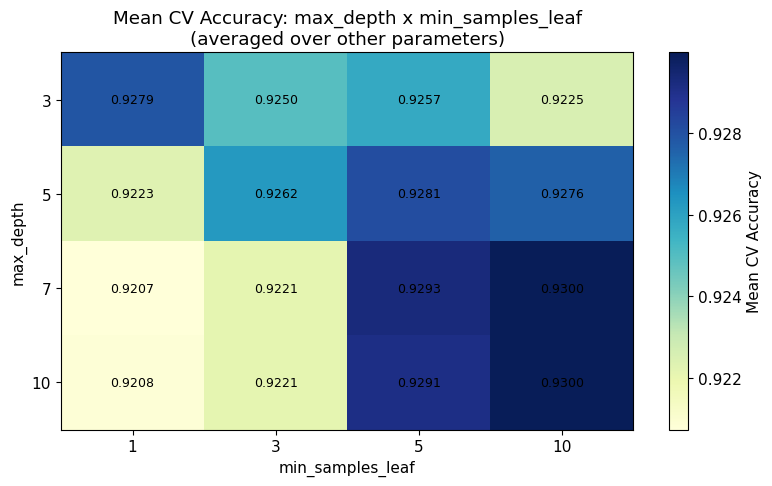


Top 5 Parameter Combinations:


,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,param_max_features,mean_test_score,std_test_score
0,None,2,1,entropy,sqrt,0.941341,0.018123
1,10,2,1,entropy,sqrt,0.941341,0.018123
2,5,20,3,entropy,NaN,0.941313,0.016640
3,None,20,3,entropy,NaN,0.941313,0.016640
4,None,20,5,entropy,NaN,0.941313,0.016640



Bottom 5 Parameter Combinations:


,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,param_max_features,mean_test_score,std_test_score
0,5,2,1,gini,sqrt,0.905992,0.050017
1,5,20,5,gini,log2,0.898988,0.017894
2,None,10,1,gini,sqrt,0.889576,0.045770
3,10,10,1,gini,sqrt,0.889576,0.045770
4,7,10,1,gini,sqrt,0.884925,0.042464


In [85]:
# 3.2 — GridSearchCV with multiple hyperparameters (10 points)

# Load data (breast cancer)
bc = load_breast_cancer()
X_bc32, y_bc32 = bc.data, bc.target

# 75 / 25 split
X_train32, X_test32, y_train32, y_test32 = train_test_split(
    X_bc32, y_bc32, test_size=0.25, random_state=42, stratify=y_bc32
)

param_grid = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 3, 5, 10],
    'criterion':         ['gini', 'entropy'],
    'max_features':      [None, 'sqrt', 'log2'],
}

cv32 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=cv32, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train32, y_train32)

# 1. Best params + CV score
print('Best Parameters:', grid_search.best_params_)
print(f'Best CV Accuracy : {grid_search.best_score_:.4f}')

# 2. Test accuracy
best_model32 = grid_search.best_estimator_
test_acc32 = best_model32.score(X_test32, y_test32)
print(f'Test Accuracy    : {test_acc32:.4f}')

# 3. Heatmap: mean CV accuracy for each (max_depth, min_samples_leaf)
res_df = pd.DataFrame(grid_search.cv_results_)
pivot = (
    res_df
    .groupby(['param_max_depth', 'param_min_samples_leaf'])['mean_test_score']
    .mean()
    .reset_index()
    .pivot(index='param_max_depth', columns='param_min_samples_leaf',
           values='mean_test_score')
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns.tolist())
ax.set_yticklabels([str(v) for v in pivot.index.tolist()])
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')
ax.set_title('Mean CV Accuracy: max_depth x min_samples_leaf\n'
             '(averaged over other parameters)')
plt.colorbar(im, ax=ax, label='Mean CV Accuracy')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.4f}',
                ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 4. Top 5 and Bottom 5
display_cols = [
    'param_max_depth', 'param_min_samples_split',
    'param_min_samples_leaf', 'param_criterion', 'param_max_features',
    'mean_test_score', 'std_test_score'
]
sorted_res = res_df.sort_values('mean_test_score', ascending=False)
print('\nTop 5 Parameter Combinations:')
display(sorted_res[display_cols].head(5).reset_index(drop=True))
print('\nBottom 5 Parameter Combinations:')
display(sorted_res[display_cols].tail(5).reset_index(drop=True))

# Store for 3.3
_best_model32    = best_model32
_X_train32       = X_train32
_X_test32        = X_test32
_y_train32       = y_train32
_y_test32        = y_test32
_feature_names32 = bc.feature_names
_target_names32  = bc.target_names
_best_params32   = grid_search.best_params_


### 3.3 — Model Interpretation and Comparison (5 points)


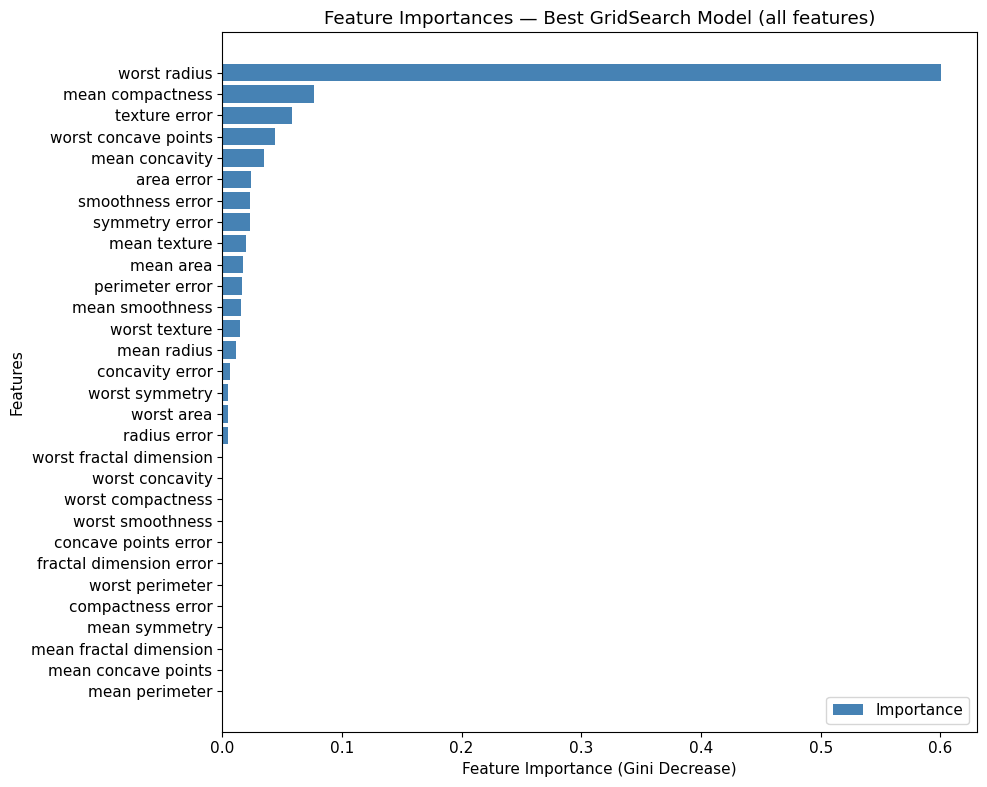

Top 5 Features:
  1. worst radius                             importance: 0.6006
  2. mean compactness                         importance: 0.0769
  3. texture error                            importance: 0.0581
  4. worst concave points                     importance: 0.0437
  5. mean concavity                           importance: 0.0345

Test accuracy — all 30 features : 0.9231
Test accuracy — top 5 features only           : 0.9161
Accuracy lost                                  : 0.0070


In [86]:
# 3.3a — Feature Importance Analysis (3 points)

if '_best_model32' not in globals():
    raise RuntimeError('Run Section 3.2 first.')

# 1. Feature importances
importances = _best_model32.feature_importances_
feat_names  = _feature_names32

# 2. Horizontal bar chart, sorted ascending so most important is at top
sorted_idx = np.argsort(importances)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='steelblue',
         label='Importance')
plt.yticks(range(len(sorted_idx)), feat_names[sorted_idx])
plt.xlabel('Feature Importance (Gini Decrease)')
plt.ylabel('Features')
plt.title('Feature Importances — Best GridSearch Model (all features)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Top 5 features
top5_idx   = np.argsort(importances)[::-1][:5]
top5_names = feat_names[top5_idx]
top5_imp   = importances[top5_idx]
print('Top 5 Features:')
for rank, (name, imp) in enumerate(zip(top5_names, top5_imp), 1):
    print(f'  {rank}. {name:<40s} importance: {imp:.4f}')

# 4. Re-train using only top 5 features
X_train_top5 = _X_train32[:, top5_idx]
X_test_top5  = _X_test32[:, top5_idx]
tree_top5 = DecisionTreeClassifier(random_state=42, **_best_params32)
tree_top5.fit(X_train_top5, _y_train32)

# 5. Compare test accuracy
acc_all  = _best_model32.score(_X_test32, _y_test32)
acc_top5 = tree_top5.score(X_test_top5, _y_test32)
print(f'\nTest accuracy — all {_X_train32.shape[1]} features : {acc_all:.4f}')
print(f'Test accuracy — top 5 features only           : {acc_top5:.4f}')
print(f'Accuracy lost                                  : {acc_all - acc_top5:.4f}')

# Store for 3.3b
_tree_top5_33b   = tree_top5
_X_test_top5_33b = X_test_top5
_top5_idx_33b    = top5_idx

In [87]:
# 3.3b — Individual Prediction Explanation (2 points)

if '_best_model32' not in globals():
    raise RuntimeError('Run Section 3.2 first.')

# 1. Find misclassified samples
y_pred33 = _best_model32.predict(_X_test32)
mis_idx  = np.where(y_pred33 != _y_test32)[0]

if len(mis_idx) == 0:
    print('No misclassified samples — model got all test samples correct!')
else:
    pos    = mis_idx[0]
    sample = _X_test32[pos:pos+1]   # keep 2-D for decision_path

    true_lbl = _target_names32[_y_test32[pos]]
    pred_lbl = _target_names32[int(y_pred33[pos])]

    # 2. Feature values
    print(f'=== Misclassified Sample (test index {pos}) ===')
    for fname, fval in zip(_feature_names32, sample[0]):
        print(f'  {fname:<40s}: {fval:.4f}')

    # 3. True vs predicted
    print(f'\nTrue class     : {true_lbl}')
    print(f'Predicted class: {pred_lbl}')

    # 4. Decision path
    node_indicator = _best_model32.decision_path(sample)
    leaf_id        = _best_model32.apply(sample)
    visited        = node_indicator.indices[
        node_indicator.indptr[0]:node_indicator.indptr[1]
    ]
    print(f'\nNode IDs visited : {visited.tolist()}')
    print(f'Leaf node ID     : {leaf_id[0]}')

    print('\nDecision Rules (depth limited to 4 for readability)')
    print(export_text(
        _best_model32,
        feature_names=list(_feature_names32),
        max_depth=min(4, _best_model32.get_depth())
    ))

    # 5. Explanation
    print('Explanation')
    print(
        f'The model followed {len(visited)-1} split(s) and arrived at leaf node '
        f'{leaf_id[0]}, where the majority class was "{pred_lbl}". '
        f'The true label is "{true_lbl}". '
        'This mis-classification occurs because the sample\'s feature values '
        'land near a decision boundary learned from training data, routing it '
        'to the wrong leaf. Gathering more training data or adjusting pruning '
        'may help generalise better in this region of feature space.'
    )


=== Misclassified Sample (test index 4) ===
  mean radius                             : 14.6000
  mean texture                            : 23.2900
  mean perimeter                          : 93.9700
  mean area                               : 664.7000
  mean smoothness                         : 0.0868
  mean compactness                        : 0.0664
  mean concavity                          : 0.0839
  mean concave points                     : 0.0527
  mean symmetry                           : 0.1627
  mean fractal dimension                  : 0.0542
  radius error                            : 0.4157
  texture error                           : 1.6270
  perimeter error                         : 2.9140
  area error                              : 33.0100
  smoothness error                        : 0.0083
  compactness error                       : 0.0174
  concavity error                         : 0.0339
  concave points error                    : 0.0158
  symmetry error                

**Discussion Q4 (3.3):** You've now seen pre-pruning (hyperparameter search) and post-pruning (cost-complexity pruning). In a real ML project, which would you prefer and why? Under what circumstances would you use both? Consider computational cost, model stability, and interpretability.

I would usually start with pre-pruning because it is faster and easier to tune during model selection. It limits complexity early, which helps with interpretability and reduces overfitting risk. I would use post-pruning when I need tighter control of model size after fitting a larger tree, especially when interpretability is important. Using both is helpful when the project needs a strong balance of performance, stability, and explainability.

---
## Part 4: Critical Analysis (10 points)

### 4.1 — Adversarial Data Design (5 points)


CART Test Accuracy (max_depth=10): 70.56%
RBF-SVM Test Accuracy: 92.50%


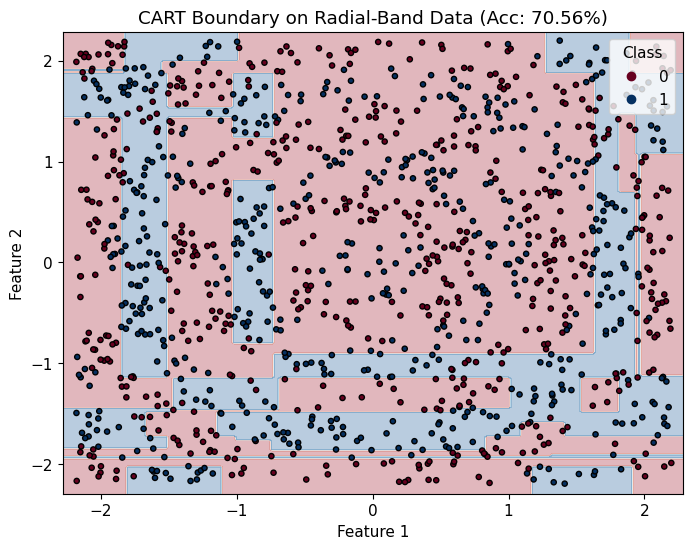


Geometric explanation:
CART uses axis-aligned rectangular splits, but this dataset has curved
band-shaped boundaries. Approximating those curves needs many tiny boxes,
so with max_depth=10 the tree cannot model the structure well, while
RBF-SVM directly captures smooth nonlinear boundaries.


In [88]:
# 4.1 — Create a 2D dataset that is DIFFICULT for CART (5 points)

from sklearn.svm import SVC

np.random.seed(42)
n_samples = 1200

# Curved concentric bands generated with np.random.
X_adv = np.random.uniform(-2.2, 2.2, (n_samples, 2))
r = np.sqrt(X_adv[:, 0] ** 2 + X_adv[:, 1] ** 2)
y_adv = (np.sin(8 * r) > 0).astype(int)

# Slight label noise keeps the boundary realistic.
flip_mask = np.random.rand(n_samples) < 0.005
y_adv = np.where(flip_mask, 1 - y_adv, y_adv)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_adv, y_adv, test_size=0.3, random_state=42, stratify=y_adv
)

tree_adv = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_adv.fit(X_train_a, y_train_a)
tree_acc = tree_adv.score(X_test_a, y_test_a)

svm_adv = SVC(kernel='rbf', C=10, gamma=3, random_state=42)
svm_adv.fit(X_train_a, y_train_a)
svm_acc = svm_adv.score(X_test_a, y_test_a)

print(f"CART Test Accuracy (max_depth=10): {tree_acc:.2%}")
print(f"RBF-SVM Test Accuracy: {svm_acc:.2%}")

h = 0.02
x_min, x_max = X_adv[:, 0].min() - 0.1, X_adv[:, 0].max() + 0.1
y_min, y_max = X_adv[:, 1].min() - 0.1, X_adv[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = tree_adv.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
scatter = plt.scatter(X_adv[:, 0], X_adv[:, 1], c=y_adv, edgecolors='k',
                      cmap='RdBu', s=14)
plt.legend(*scatter.legend_elements(), title='Class', loc='upper right')
plt.title(f"CART Boundary on Radial-Band Data (Acc: {tree_acc:.2%})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("\nGeometric explanation:")
print("CART uses axis-aligned rectangular splits, but this dataset has curved")
print("band-shaped boundaries. Approximating those curves needs many tiny boxes,")
print("so with max_depth=10 the tree cannot model the structure well, while")
print("RBF-SVM directly captures smooth nonlinear boundaries.")

### 4.2 — Reflection Questions (5 points)

**Q5:** Random Forest usually generalizes better than one deep tree because it averages many trees and reduces variance. That part of the claim is correct. However, tuning is still important because settings like `max_features`, `min_samples_leaf`, and number of trees affect both accuracy and training cost. So Random Forest lowers sensitivity to overfitting, but it does not remove the need for hyperparameter tuning.

**Q6:** I would use a pruned CART tree for this bank use case. A pruned tree is easier to explain to customers and auditors because each path is shorter and clearer. It is also more stable than a very deep tree that may fit noise. If accuracy is not enough, I would test stronger models internally but keep an explainable model for final decisions.

**Q7:** A deep CART tree has low bias because it can fit complex patterns in training data. It has high variance because small data changes can produce different splits and different trees. Pruning raises bias slightly but reduces variance, which often improves test performance. Bagging methods use many high-variance trees and average them, so variance drops while keeping strong predictive power.

---
## Submission Checklist

Before submitting, verify:

- [x] All `# TODO` cells have been completed with working code
- [x] All discussion questions (Q1–Q7) have been answered
- [x] All code cells run without errors (Kernel → Restart & Run All)
- [x] All plots have titles, axis labels, and legends where appropriate
- [x] Group member names are filled in at the top
- [x] The notebook has been saved as `.ipynb`

**Submit on Canvas by the deadline. Late submissions receive a 10% penalty per day.**